# Distillation by metrics — reasoning evals (with synthetic-trace baselines)

Plots `summary_reasoning_evals*.json` results for the `distillation_by_metrics`
group, one graph per model (e.g. `qwen_3b_head_truncated8192`).

Each metric-driven run is evaluated at several **thinking-token caps**
(`max_thinking_tokens` at eval time) and **every cap is drawn as its own curve**.
The cap is parsed from the summary filename: bare `summary_reasoning_evals.json` is
the default cap **8192**, and `summary_reasoning_evals_cap<N>.json` is cap `N`.
Within a figure **colour encodes the experiment** (e.g. `entropy_gain`, `random`,
`student_entropy`) and **line style encodes the cap**, so one experiment keeps a
single colour across caps. For context, two baseline experiments from the
`distillation_on_synthetic_traces` group — `direct_reasoning_trace` and
`corrected_answer` — are overlaid for the matching model and dataset, split by cap
the same way and drawn faded / thin / behind so the two families stay easy to tell
apart. Baselines are **restricted to the caps the metric-driven runs were evaluated
at** (per model), so every baseline curve has a matching-cap metric-driven
counterpart; baseline runs at any other cap (e.g. a cap-1024 baseline when the
metric-driven runs only used 2048/4096) are dropped.

The **X axis is "training samples seen"**, not epochs: the two groups consume very
different amounts of data per epoch, so each curve's epoch is multiplied by its
samples-per-epoch — 1024 for `distillation_by_metrics` (top-k resampled per epoch)
and 9626 for the full-dataset baselines. This compares the runs at an equal data
budget. The metric-driven curve therefore sits in the far-left (low-sample) region
of the axis — that compression is the point: it reaches comparable accuracy with an
order of magnitude less data.

When a matching `base_model/<model>_cot` folder exists, epoch 0 is the base model
evaluated with chain-of-thought (taken from the synthetic-traces group, since the
by-metrics group has no `base_model` of its own); it anchors the default-cap curve
at x=0 and is drawn as a dashed gray reference line. Note the truncation-variant
model names used here (e.g. `qwen_3b_head_truncated8192`) have no matching
`base_model` folder — only bare base names like `qwen_3b_cot` exist — so no base
line is drawn unless that lookup is adjusted. Experiments / models / datasets are
discovered from the directory tree, so re-running picks up newly finished runs
(e.g. a future `student_entropy` variant) automatically. To analyze another group,
copy this notebook and change `GROUP_NAME`.

In [5]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt

from core.utils.graph_style import set_style

set_style()

GROUP_NAME = "distillation_by_metrics"
BASELINE_GROUP = "distillation_on_synthetic_traces"  # source of the overlay baselines + base anchor
BASELINE_EXPERIMENTS = ("direct_reasoning_trace", "corrected_answer")
SUMMARY_GLOB = "summary_reasoning_evals*.json"  # one summary file per eval cap
DEFAULT_CAP = 8192  # bare summary_reasoning_evals.json == eval cap (max_thinking_tokens) 8192
BASE_EXPERIMENT = "base_model"
BASE_SUFFIX = "_cot"  # use the *_cot base_model folders for epoch 0
METRIC = "accuracy"
SAMPLES_PER_EPOCH = 1024  # distillation_by_metrics: top-k examples resampled per epoch
BASELINE_SAMPLES_PER_EPOCH = 9626  # synthetic-trace baselines: full dataset per epoch
SAVE = True  # also write PNGs under artifacts/<group>/<dataset>/plots/


def find_artifacts_dir(start: Path | None = None) -> Path:
    """Walk up from `start` (cwd by default) until an `artifacts/` dir is found."""
    start = (start or Path.cwd()).resolve()
    for d in [start, *start.parents]:
        if (d / "artifacts").is_dir():
            return d / "artifacts"
    raise FileNotFoundError("artifacts/ not found above cwd")


ARTIFACTS = find_artifacts_dir()
GROUP_DIR = ARTIFACTS / GROUP_NAME
BASELINE_GROUP_DIR = ARTIFACTS / BASELINE_GROUP
GROUP_DIR

PosixPath('/Users/aigoncharov/dev/sktech/recursive_caft/artifacts/distillation_by_metrics')

In [6]:
CAP_RE = re.compile(r"summary_reasoning_evals(?:_cap(\d+))?\.json$")  # eval cap from filename


def load_curves(dataset_dir: Path) -> dict:
    """model -> experiment -> {(cap, eval_key): sorted [(epoch, metric)]}.

    Every `summary_reasoning_evals*.json` in a model dir is read and its eval cap
    parsed from the filename (bare file == DEFAULT_CAP), so each cap becomes its own
    curve. Skips the base_model folder and any model dir without a finished summary.
    """
    data: dict = {}
    for exp_dir in sorted(dataset_dir.iterdir()):
        if not exp_dir.is_dir() or exp_dir.name == BASE_EXPERIMENT:
            continue
        for model_dir in sorted(exp_dir.iterdir()):
            if not model_dir.is_dir():
                continue
            for summary in sorted(model_dir.glob(SUMMARY_GLOB)):
                cm = CAP_RE.search(summary.name)
                if not cm:
                    continue  # unrecognized summary variant
                cap = int(cm.group(1)) if cm.group(1) else DEFAULT_CAP
                content = json.loads(summary.read_text())
                for eval_key, records in content.items():
                    points = sorted(
                        (r["epoch"], r[METRIC])
                        for r in records
                        if r.get("epoch") is not None and r.get(METRIC) is not None
                    )
                    if points:
                        data.setdefault(model_dir.name, {}).setdefault(exp_dir.name, {})[(cap, eval_key)] = points
    return data


def load_base(dataset_dir: Path, model: str) -> dict:
    """eval_key -> epoch-0 accuracy from the *_cot base_model folder."""
    out: dict = {}
    base_dir = dataset_dir / BASE_EXPERIMENT / f"{model}{BASE_SUFFIX}"
    if base_dir.is_dir():
        for results in sorted(base_dir.glob("*/results.json")):
            out[results.parent.name] = json.loads(results.read_text())[METRIC]
    return out

In [7]:
# Baselines come from a different group and consume the full 9626-row dataset per
# epoch, vs. 1024 resampled per epoch for distillation_by_metrics. They keep the
# same encoding (colour = experiment, linestyle = cap) but are drawn faded / thin /
# behind the metric-driven curves so the two families are easy to tell apart.
BASELINE_KW = dict(alpha=0.5, linewidth=1.4, zorder=1)

LINESTYLES = ["-", "--", "-.", ":"]  # one per eval cap
CMAP = plt.get_cmap("tab10")  # one colour per experiment


def load_baseline_curves(dataset: str) -> dict:
    """Baseline-group curves for `dataset`, restricted to BASELINE_EXPERIMENTS.

    Same shape as load_curves (model -> experiment -> {(cap, eval_key): points}).
    Empty if the baseline dataset is absent.
    """
    baseline_dataset_dir = BASELINE_GROUP_DIR / dataset
    if not baseline_dataset_dir.is_dir():
        return {}
    out: dict = {}
    for model, exps in load_curves(baseline_dataset_dir).items():
        kept = {e: pts for e, pts in exps.items() if e in BASELINE_EXPERIMENTS}
        if kept:
            out[model] = kept
    return out


def plot_curve(ax, points, base, eval_key, samples_per_epoch, label, **kw):
    """Plot one (epoch, metric) curve on the *training-samples-seen* X axis.

    Prepends the epoch-0 base anchor when available, then converts every epoch to
    cumulative samples via `epoch * samples_per_epoch` (epoch 0 -> x=0). Only the
    default-cap curve has a matching base key, so cap-specific curves stay
    unanchored (the base model was evaluated at the default cap only).
    """
    xs = [e for e, _ in points]
    ys = [v for _, v in points]
    if eval_key in base:  # anchor the (default-cap) curve at the epoch-0 base
        xs = [0.0] + xs
        ys = [base[eval_key]] + ys
    xs = [e * samples_per_epoch for e in xs]
    ax.plot(xs, ys, label=label, **kw)

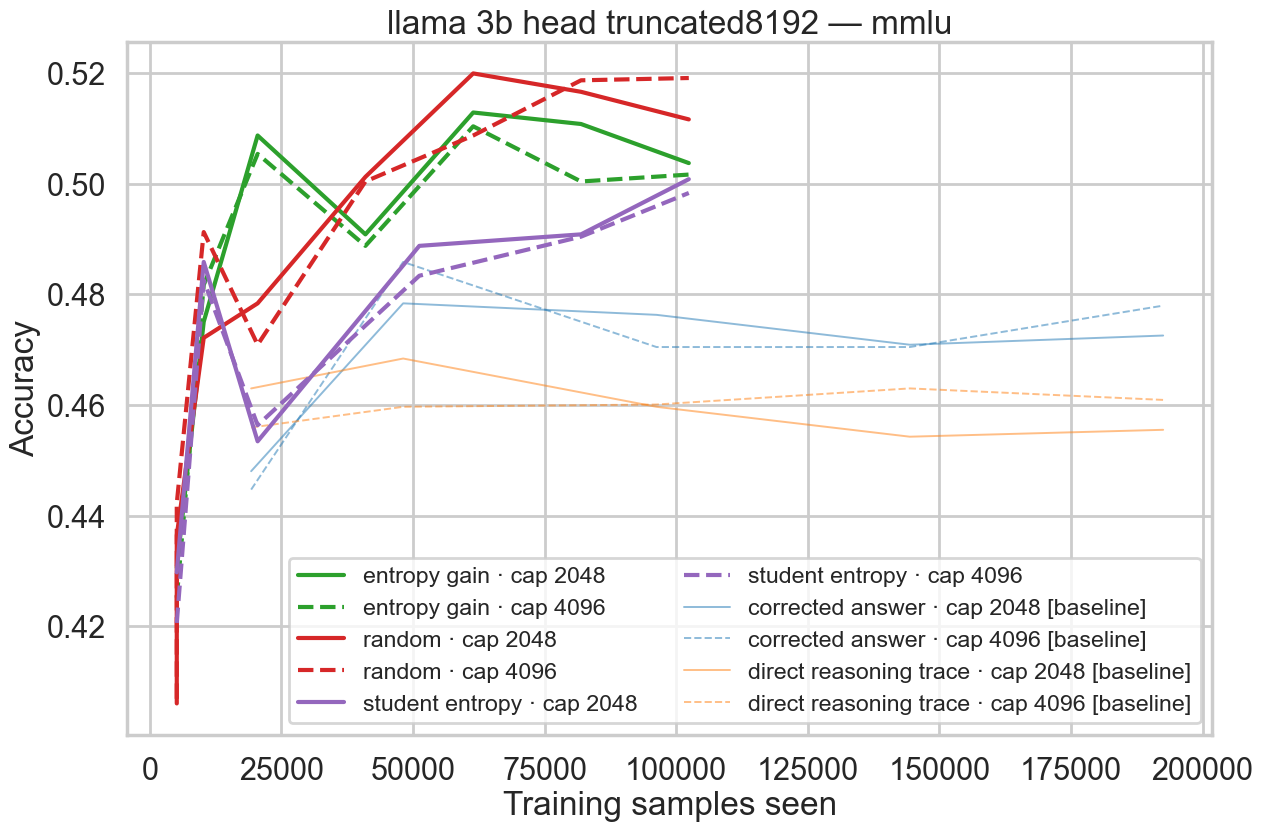

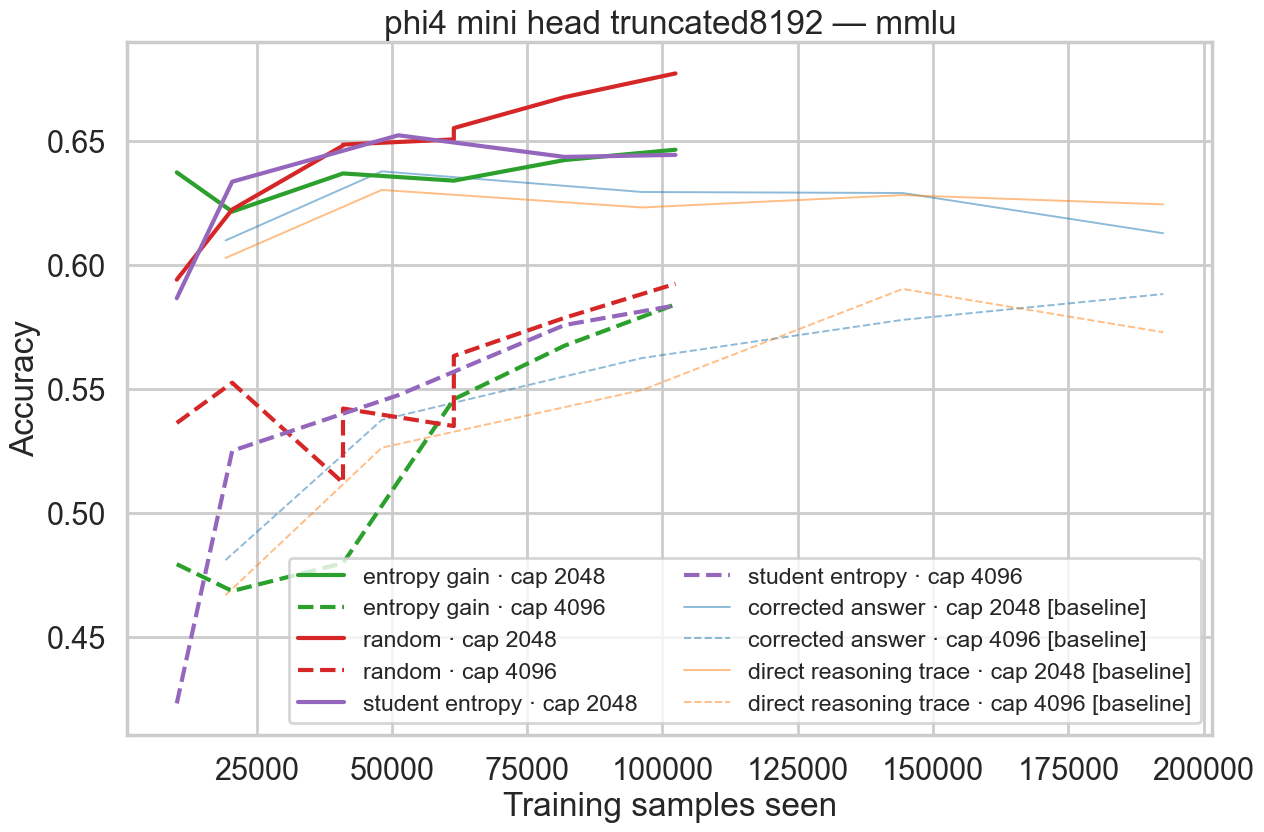

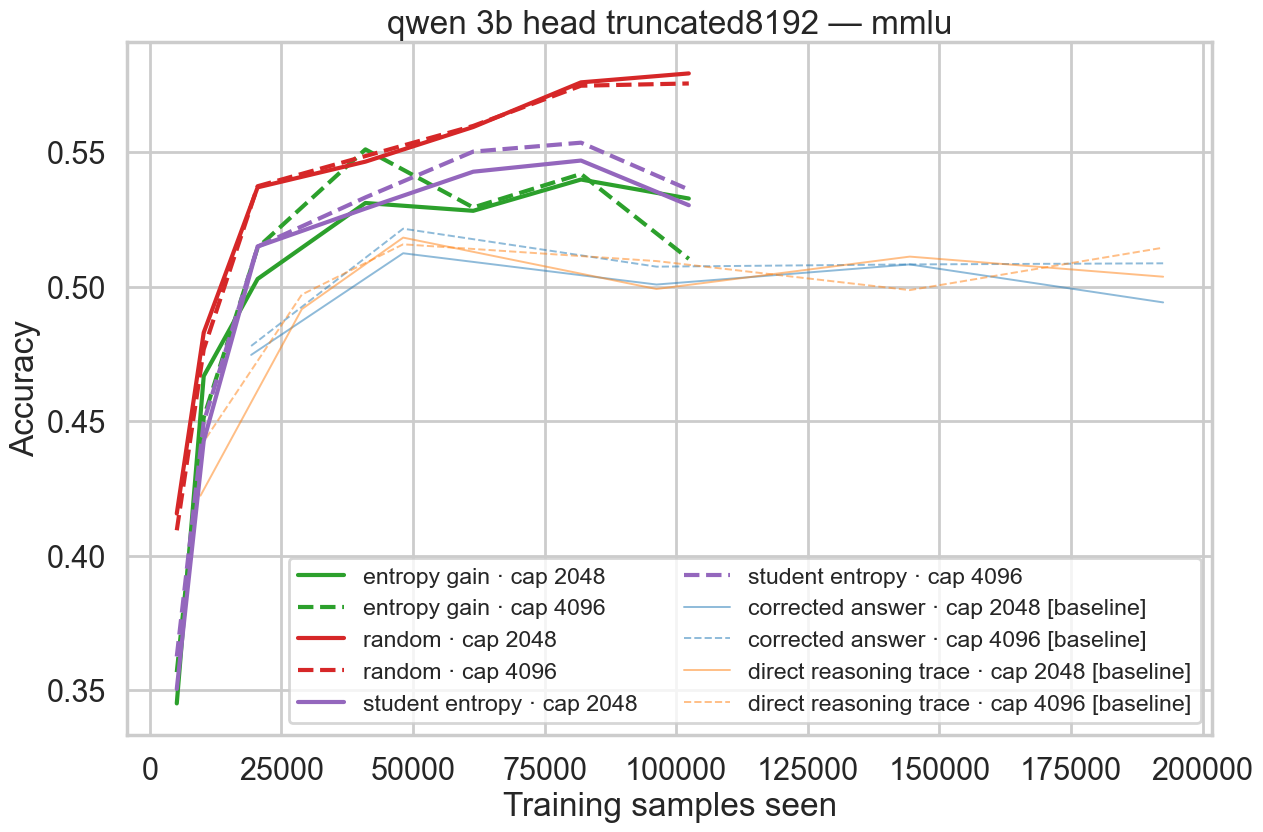

In [8]:
datasets = sorted(p.name for p in GROUP_DIR.iterdir() if p.is_dir())

for dataset in datasets:
    dataset_dir = GROUP_DIR / dataset
    curves = load_curves(dataset_dir)  # by-metrics runs drive which figures exist
    baseline_curves = load_baseline_curves(dataset)  # synthetic-trace overlays

    for model in sorted(curves):
        # base anchor comes from the baseline group (by-metrics has no base_model)
        base = load_base(BASELINE_GROUP_DIR / dataset, model)

        # only overlay baselines at caps the metric-driven runs were evaluated at,
        # so every baseline curve has a matching-cap metric-driven counterpart
        main_caps = {cap for exp in curves[model].values() for cap, _ in exp}
        model_baselines = {
            experiment: {k: pts for k, pts in cap_curves.items() if k[0] in main_caps}
            for experiment, cap_curves in baseline_curves.get(model, {}).items()
        }
        model_baselines = {e: c for e, c in model_baselines.items() if c}  # drop emptied experiments

        # stable visual mapping across the whole figure:
        #   colour    = experiment (metric-driven & baseline experiments each get one)
        #   linestyle = eval cap
        experiments = sorted(set(curves[model]) | set(model_baselines))
        exp_color = {e: CMAP(i % CMAP.N) for i, e in enumerate(experiments)}
        cap_ls = {cap: LINESTYLES[i % len(LINESTYLES)] for i, cap in enumerate(sorted(main_caps))}

        fig, ax = plt.subplots(figsize=(14, 9))

        # metric-driven curves (distillation_by_metrics) — solid family, full colour
        for experiment in sorted(curves[model]):
            for (cap, eval_key), points in sorted(curves[model][experiment].items()):
                plot_curve(
                    ax, points, base, eval_key, SAMPLES_PER_EPOCH,
                    label=f"{experiment.replace('_', ' ')} · cap {cap}",
                    color=exp_color[experiment], ls=cap_ls[cap],
                )

        # baseline curves (distillation_on_synthetic_traces) — same colour/style, faded + behind
        for experiment in sorted(model_baselines):
            for (cap, eval_key), points in sorted(model_baselines[experiment].items()):
                plot_curve(
                    ax, points, base, eval_key, BASELINE_SAMPLES_PER_EPOCH,
                    label=f"{experiment.replace('_', ' ')} · cap {cap} [baseline]",
                    color=exp_color[experiment], ls=cap_ls[cap], **BASELINE_KW,
                )

        for eval_key, acc in base.items():  # base reference line(s), default cap only
            ax.axhline(acc, ls="--", color="gray", alpha=0.7, label="base model (CoT)")

        ax.set_title(f"{model.replace('_', ' ')} — {dataset}")
        ax.set_xlabel("Training samples seen")
        ax.set_ylabel(METRIC.capitalize())
        ax.legend(fontsize="x-small", loc="best", ncol=2)

        if SAVE:
            plots_dir = dataset_dir / "plots"
            plots_dir.mkdir(parents=True, exist_ok=True)
            fig.savefig(
                plots_dir / f"{model}_reasoning_evals.png",
                bbox_inches="tight",
                dpi=150,
            )

        plt.show()